# Explore here

In [52]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [54]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv"

df = pd.read_csv(url)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [55]:
df.shape

(1338, 7)

In [56]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

EXPLORACIÓN Y LIMPIEZA DE DATOS

In [57]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [58]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [59]:
print("Filas antes de eliminar duplicados:", df.shape[0])
df = df.drop_duplicates()
print("Filas después de eliminar duplicados:", df.shape[0])

Filas antes de eliminar duplicados: 1338
Filas después de eliminar duplicados: 1337


In [60]:
df.info()

<class 'pandas.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   str    
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   str    
 5   region    1337 non-null   str    
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 83.6 KB


ANÁLISIS DE VARIABLES UNIVARIANTE

Distribución sex:
 sex
male      675
female    662
Name: count, dtype: int64


/tmp/ipykernel_1813/4050586126.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sex', ax=axes[0], palette='pastel')


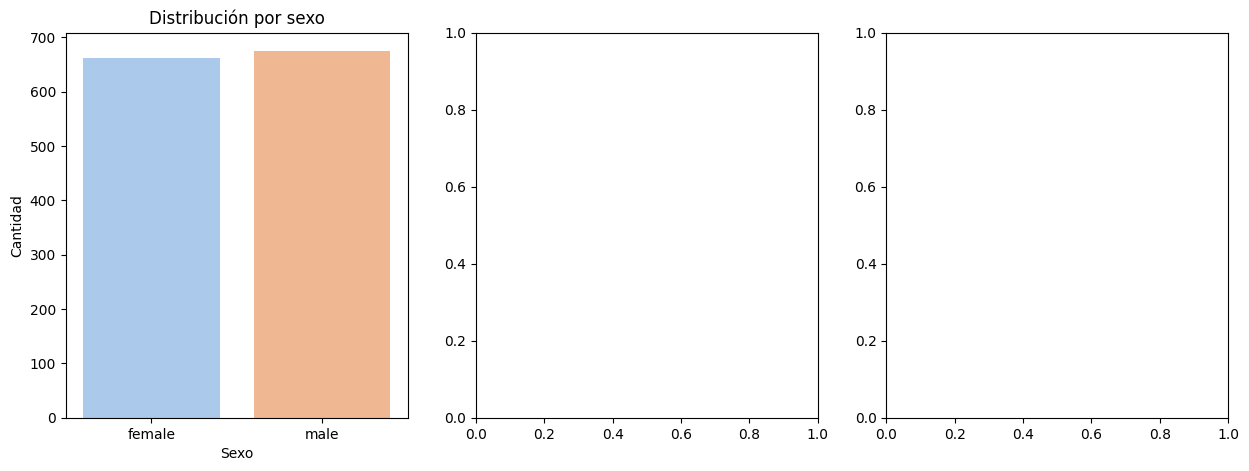

In [61]:
#VARIABLES CATEGÓRICAS
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.countplot(data=df, x='sex', ax=axes[0], palette='pastel')
axes[0].set_title('Distribución por sexo')
axes[0].set_xlabel('Sexo')
axes[0].set_ylabel('Cantidad')
print("Distribución sex:\n", df['sex'].value_counts())

In [62]:
sns.countplot(data=df, x='smoker', ax=axes[1], palette='pastel')
axes[1].set_title('Distribución fumadores')
axes[1].set_xlabel('¿Fumador?')
axes[1].set_ylabel('Cantidad')

print("\nDistribución smoker:\n", df['smoker'].value_counts())


Distribución smoker:
 smoker
no     1063
yes     274
Name: count, dtype: int64


/tmp/ipykernel_1813/960381394.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='smoker', ax=axes[1], palette='pastel')


In [63]:
sns.countplot(data=df, x='region', ax=axes[2], palette='pastel')
axes[2].set_title('Distribución por región')
axes[2].set_xlabel('Región')
axes[2].set_ylabel('Cantidad')
axes[2].tick_params(axis='x', rotation=15)
print("\nDistribución region:\n", df['region'].value_counts())
plt.tight_layout()
plt.show()


Distribución region:
 region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


/tmp/ipykernel_1813/1288375959.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='region', ax=axes[2], palette='pastel')


<Figure size 640x480 with 0 Axes>

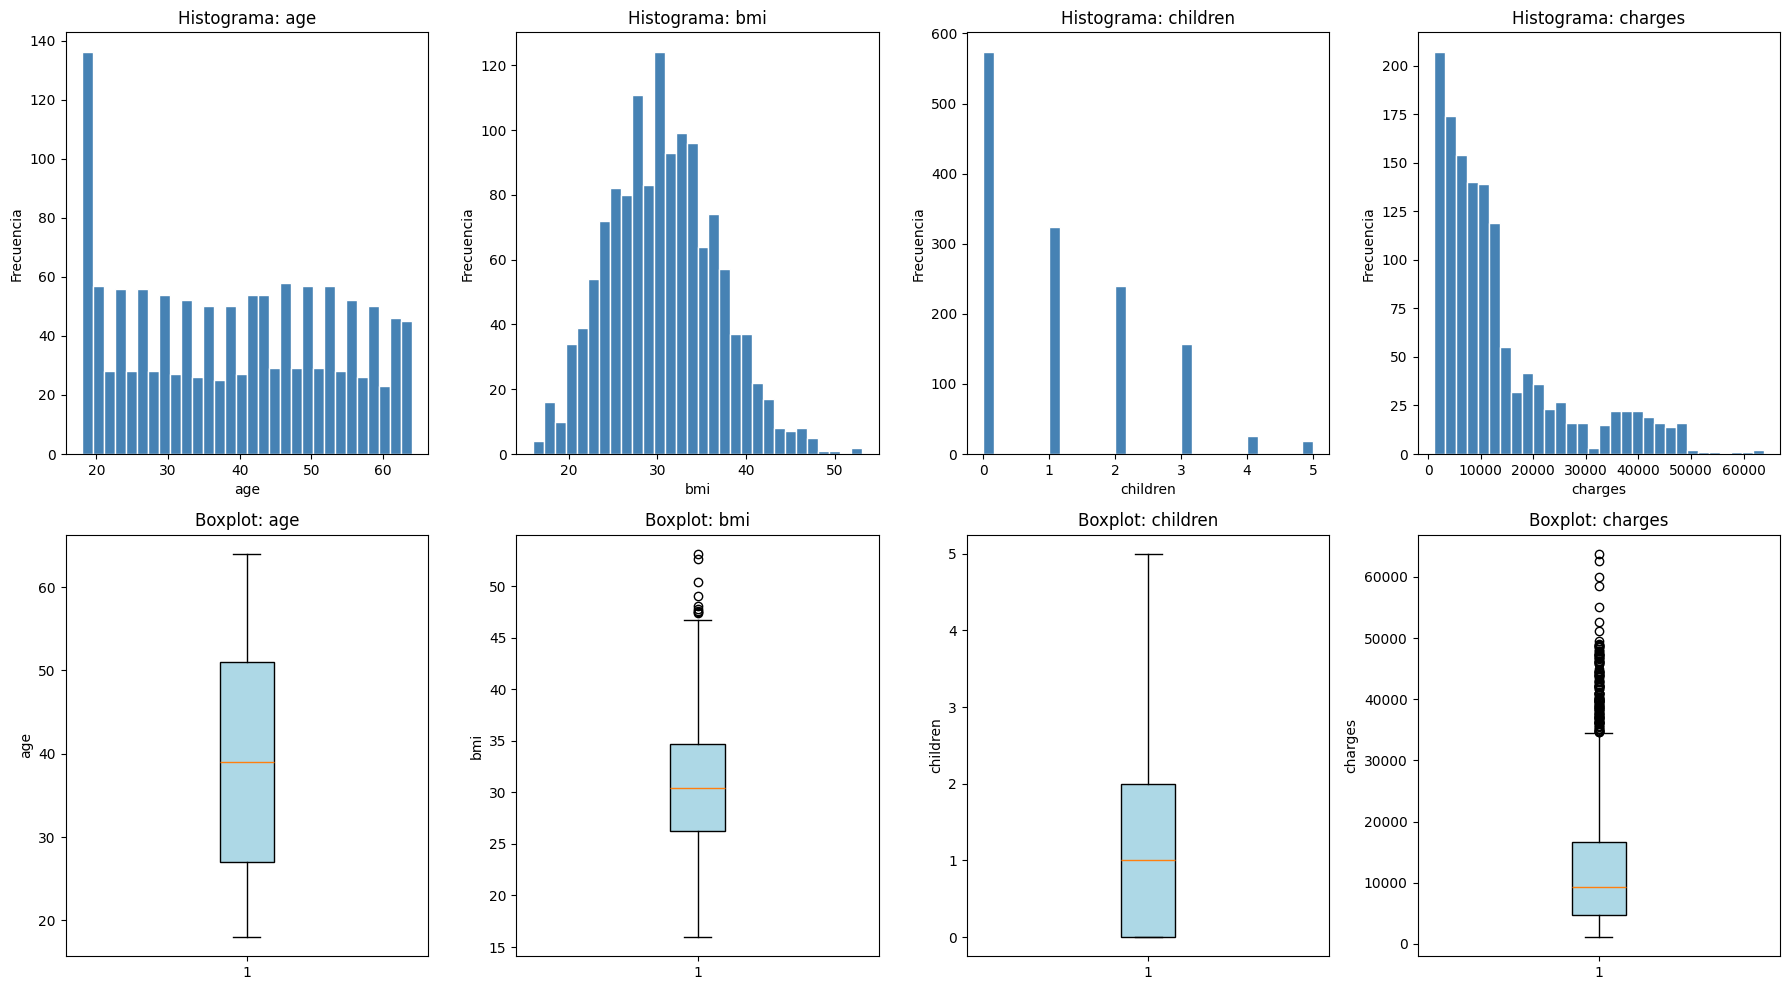

In [64]:
#VARIABLES NUMÉRICAS
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
num_cols = ['age', 'bmi', 'children', 'charges']
for i, col in enumerate(num_cols):
    axes[0, i].hist(df[col], bins=30, color='steelblue', edgecolor='white')   
    axes[0, i].set_title(f'Histograma: {col}')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frecuencia')

    axes[1, i].boxplot(df[col], patch_artist=True,
                       boxprops=dict(facecolor='lightblue'))

    axes[1, i].set_title(f'Boxplot: {col}')
    axes[1, i].set_ylabel(col)

plt.tight_layout()
plt.show()

In [65]:
for col in num_cols:
    print(f"\n{'='*40}")
    print(f"Variable: {col}")
    print(f"  Media:    {df[col].mean():.2f}")
   
    print(f"  Mediana:  {df[col].median():.2f}")

    print(f"  Std:      {df[col].std():.2f}")

    print(f"  Mín:      {df[col].min():.2f}")
    print(f"  Máx:      {df[col].max():.2f}")

    skew = df[col].skew()
    print(f"  Skewness: {skew:.2f}")


Variable: age
  Media:    39.22
  Mediana:  39.00
  Std:      14.04
  Mín:      18.00
  Máx:      64.00
  Skewness: 0.05

Variable: bmi
  Media:    30.66
  Mediana:  30.40
  Std:      6.10
  Mín:      15.96
  Máx:      53.13
  Skewness: 0.28

Variable: children
  Media:    1.10
  Mediana:  1.00
  Std:      1.21
  Mín:      0.00
  Máx:      5.00
  Skewness: 0.94

Variable: charges
  Media:    13279.12
  Mediana:  9386.16
  Std:      12110.36
  Mín:      1121.87
  Máx:      63770.43
  Skewness: 1.52


ANÁLISIS DE VARIABLES MULTIVARIANTE

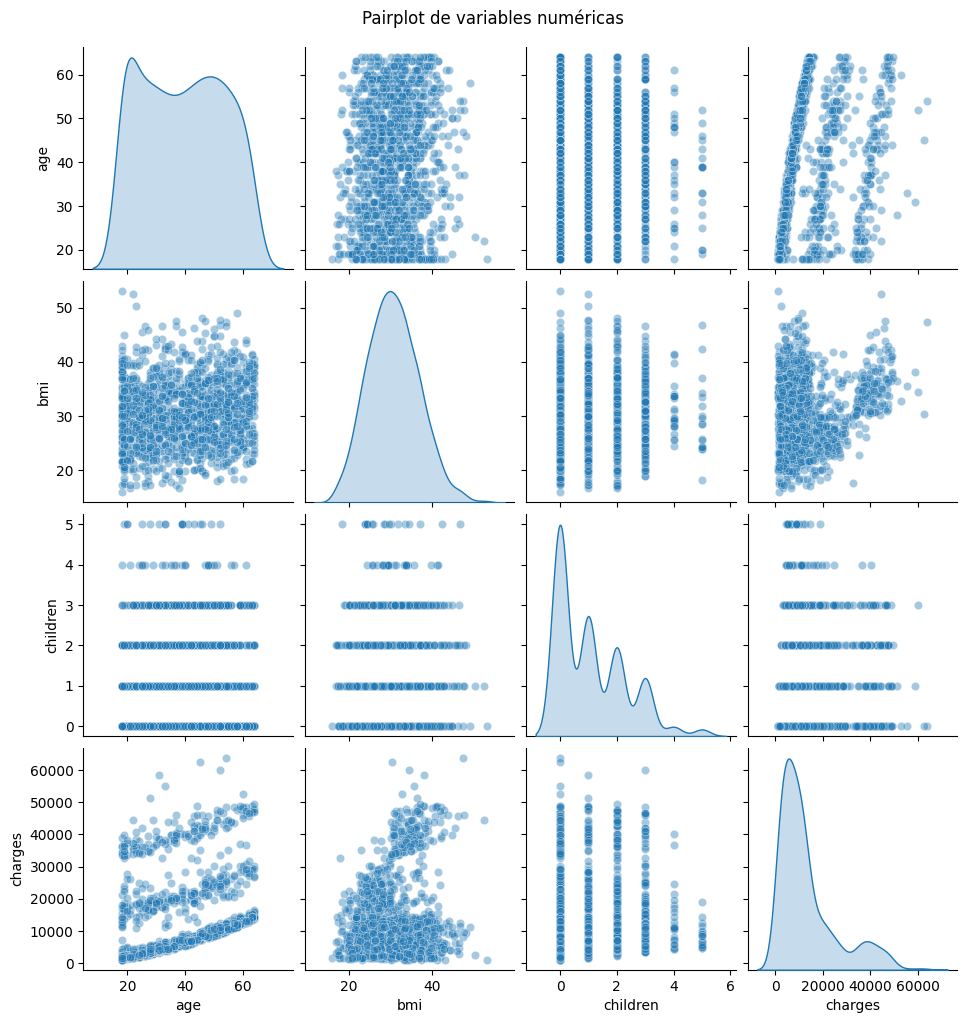

In [66]:
sns.pairplot(df[num_cols], diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle('Pairplot de variables numéricas', y=1.02)
plt.show()

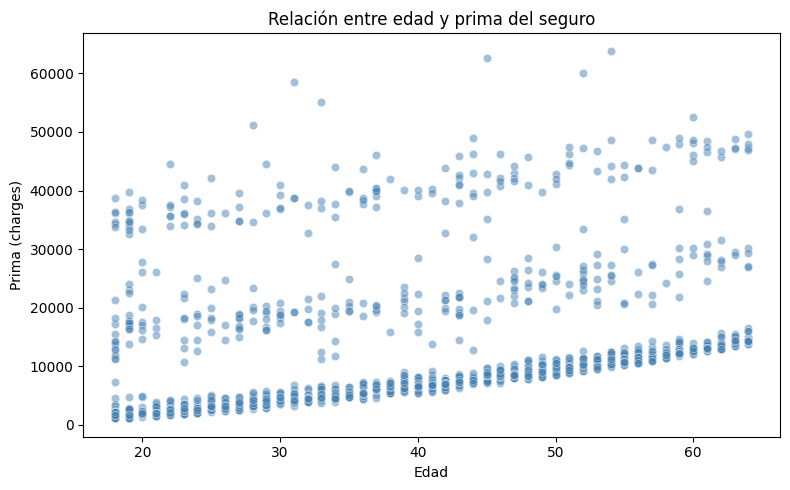

In [67]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='charges', alpha=0.5, color='steelblue')

plt.title('Relación entre edad y prima del seguro')
plt.xlabel('Edad')
plt.ylabel('Prima (charges)')
plt.tight_layout()
plt.show()

ANÁLISIS CATEGÓRICO - CATEGÓRICO

Tabla cruzada sex vs smoker:
 smoker   no  yes
sex             
female  547  115
male    516  159


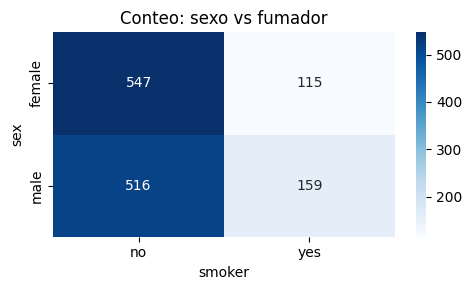

In [68]:
cross_sex_smoker = pd.crosstab(df['sex'], df['smoker'])
print("Tabla cruzada sex vs smoker:\n", cross_sex_smoker)

plt.figure(figsize=(5, 3))
sns.heatmap(cross_sex_smoker, annot=True, fmt='d', cmap='Blues')

plt.title('Conteo: sexo vs fumador')
plt.tight_layout()
plt.show()


Tabla cruzada region vs smoker:
 smoker      no  yes
region             
northeast  257   67
northwest  266   58
southeast  273   91
southwest  267   58


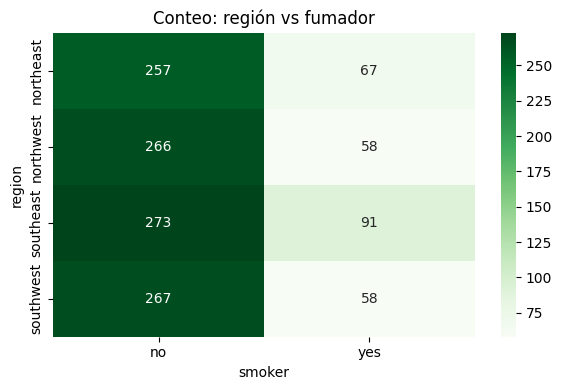

In [69]:
# region vs smoker
cross_region_smoker = pd.crosstab(df['region'], df['smoker'])
print("\nTabla cruzada region vs smoker:\n", cross_region_smoker)

plt.figure(figsize=(6, 4))
sns.heatmap(cross_region_smoker, annot=True, fmt='d', cmap='Greens')
plt.title('Conteo: región vs fumador')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1813/198646896.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='charges', ax=axes[i], palette='pastel')
/tmp/ipykernel_1813/198646896.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='charges', ax=axes[i], palette='pastel')
/tmp/ipykernel_1813/198646896.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='charges', ax=axes[i], palette='pastel')


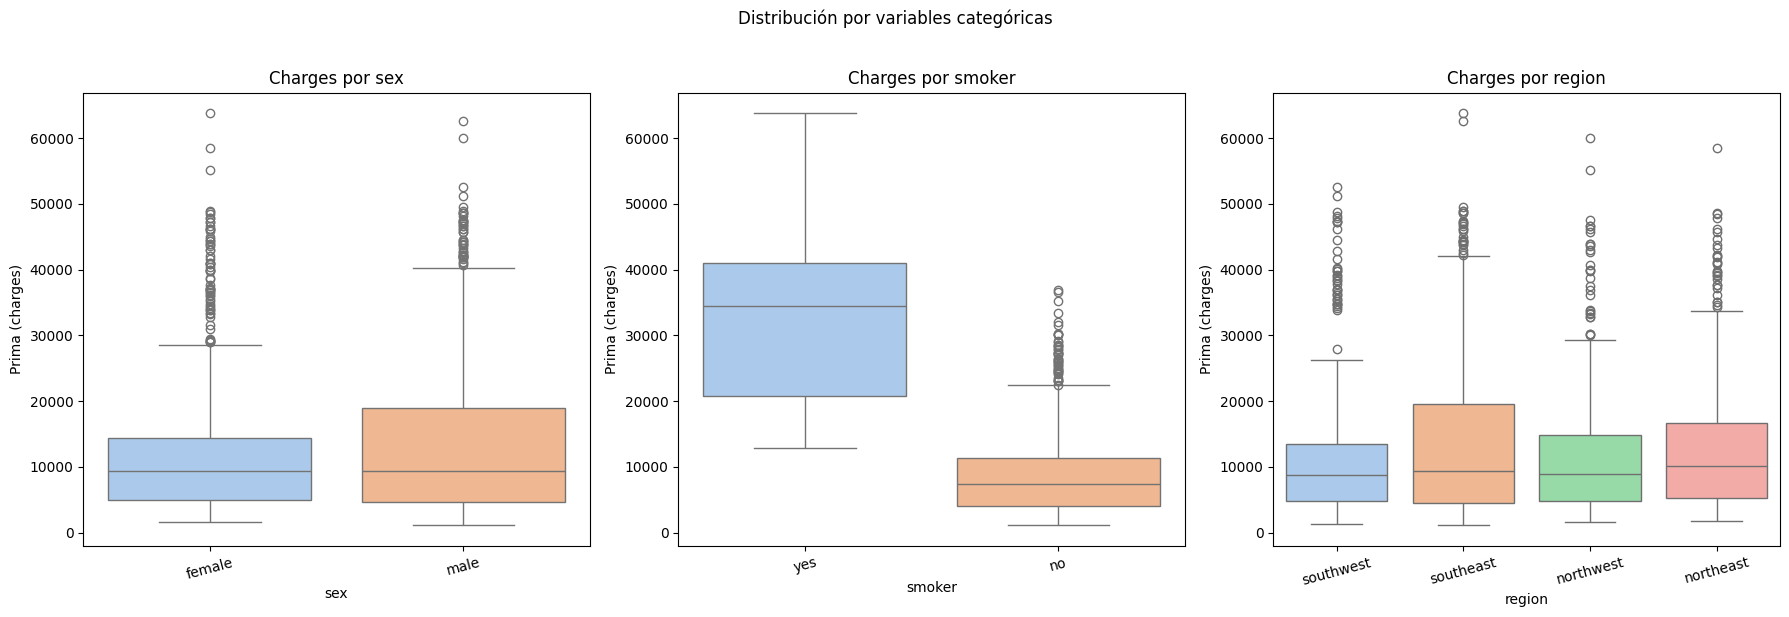

In [70]:
#COMBINACIONES DE LA CLASE (charges) CON VARIAS PREDICTORAS
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cat_cols = ['sex', 'smoker', 'region']
# Lista de variables categóricas que compararemos contra charges
for i, col in enumerate(cat_cols):

    sns.boxplot(data=df, x=col, y='charges', ax=axes[i], palette='pastel')

    axes[i].set_title(f'Charges por {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Prima (charges)')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Distribución por variables categóricas', y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1813/3365650621.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='smoker', y='charges', palette='muted', inner='box')


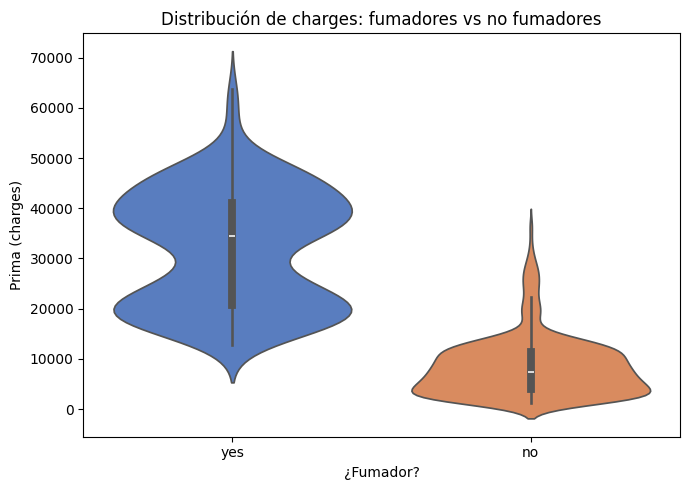

In [71]:
# smoker vs charges
plt.figure(figsize=(7, 5))
sns.violinplot(data=df, x='smoker', y='charges', palette='muted', inner='box')

plt.title('Distribución de charges: fumadores vs no fumadores')
plt.xlabel('¿Fumador?')
plt.ylabel('Prima (charges)')
plt.tight_layout()
plt.show()

Qué observaremos: las primas de fumadores serán MUCHO más altas
Esta será probablemente la variable más importante del modelo

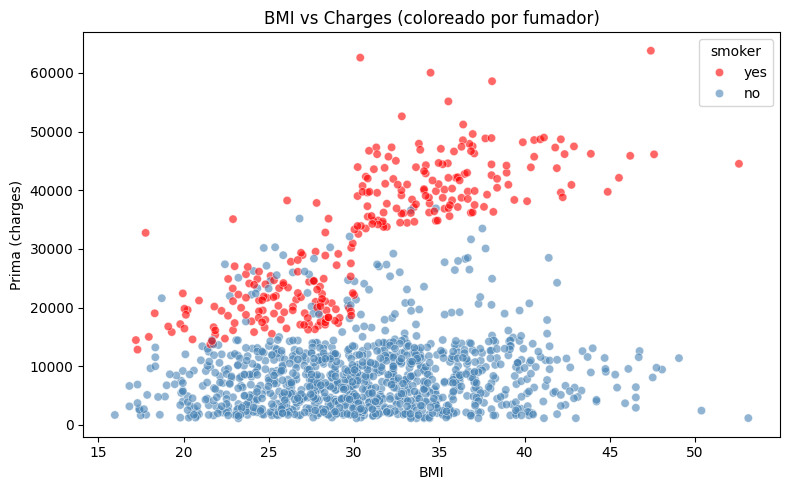

In [72]:
# ── Scatterplot: bmi vs charges, coloreado por smoker ────────
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker',
                palette={'yes': 'red', 'no': 'steelblue'}, alpha=0.6)
# hue='smoker' → colorea cada punto según si es fumador o no
# palette      → rojo para fumadores, azul para no fumadores
# Esto nos permite ver 3 variables a la vez en un solo gráfico

plt.title('BMI vs Charges (coloreado por fumador)')
plt.xlabel('BMI')
plt.ylabel('Prima (charges)')
plt.tight_layout()
plt.show()

Qué observaremos: dos nubes de puntos bien separadas
Los fumadores con BMI alto tienen primas EXTREMADAMENTE altas
Hay una interacción entre bmi y smoker → puede ser útil crear una feature combinada

In [73]:
# ANÁLISIS DE CORRELACIONES 

df_encoded = df.copy()
# Hacemos una copia para no modificar el DataFrame original

df_encoded['sex']    = df_encoded['sex'].map({'male': 1, 'female': 0})
df_encoded['smoker'] = df_encoded['smoker'].map({'yes': 1, 'no': 0})
# map() reemplaza cada valor por el número que le asignamos
# male→1, female→0 | yes→1, no→0

df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)
# get_dummies → convierte 'region' en columnas binarias (0 o 1)
# northwest → 1 si es northwest, 0 si no
# southeast → 1 si es southeast, 0 si no
# southwest → 1 si es southwest, 0 si no
# drop_first=True → elimina una categoría para evitar multicolinealidad
print(df_encoded.head())

   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    0  27.900         0       1  16884.92400             False   
1   18    1  33.770         1       0   1725.55230             False   
2   28    1  33.000         3       0   4449.46200             False   
3   33    1  22.705         0       0  21984.47061              True   
4   32    1  28.880         0       0   3866.85520              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


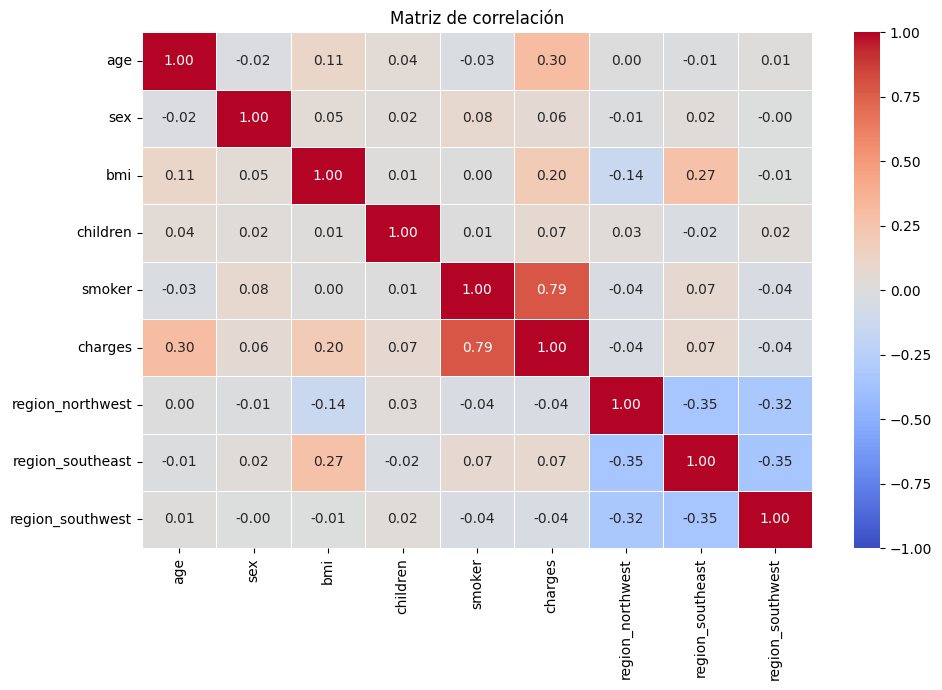

In [74]:
# Matriz de correlación 
corr_matrix = df_encoded.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,        # escribe el valor numérico en cada celda
    fmt='.2f',         # 2 decimales
    cmap='coolwarm',   # azul=correlación negativa, rojo=positiva
    center=0,          # el blanco está en 0 (sin correlación)
    linewidths=0.5,    # líneas separadoras entre celdas
    vmin=-1, vmax=1    # fuerza la escala entre -1 y 1
)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

In [75]:
print("\nCorrelación con 'charges' (de mayor a menor):")
print(corr_matrix['charges'].sort_values(ascending=False))


Correlación con 'charges' (de mayor a menor):
charges             1.000000
smoker              0.787234
age                 0.298308
bmi                 0.198401
region_southeast    0.073578
children            0.067389
sex                 0.058044
region_northwest   -0.038695
region_southwest   -0.043637
Name: charges, dtype: float64


In [76]:
# ── Conclusiones del EDA ──────────────────────────────────────
print("""
RESUMEN EDA - Conclusiones clave:
==================================
1. smoker es la variable MÁS importante → correlación ~0.79 con charges
2. age y bmi tienen correlación moderada con charges
3. children, sex y region tienen poca correlación con charges
4. La distribución de charges está muy sesgada (skewness alto)
5. Existe interacción entre bmi y smoker → posible feature engineering
6. No hay valores nulos ni duplicados relevantes → dataset limpio
""")


RESUMEN EDA - Conclusiones clave:
1. smoker es la variable MÁS importante → correlación ~0.79 con charges
2. age y bmi tienen correlación moderada con charges
3. children, sex y region tienen poca correlación con charges
4. La distribución de charges está muy sesgada (skewness alto)
5. Existe interacción entre bmi y smoker → posible feature engineering
6. No hay valores nulos ni duplicados relevantes → dataset limpio



Regresión

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Variables predictoras y objetivo
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [82]:
criterios = ['squared_error', 'friedman_mse', 'absolute_error']
resultados_reg = {}

for crit in criterios:
    tree = DecisionTreeRegressor(criterion=crit, random_state=42)
    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    resultados_reg[crit] = (mae, rmse, r2)

    print(f"\n=== Criterio: {crit} ===")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)




=== Criterio: squared_error ===
MAE: 1688.0074999216417
RMSE: 4162.717683427243
R2: 0.9056998820564518

=== Criterio: friedman_mse ===
MAE: 1664.656793652985
RMSE: 4132.318179874327
R2: 0.9070721631483106

=== Criterio: absolute_error ===
MAE: 1822.6852951082092
RMSE: 4512.93218687711
R2: 0.8891652526972053


In [83]:
best_tree = DecisionTreeRegressor(criterion='squared_error', random_state=42)
best_tree.fit(X_train, y_train)

importances = pd.Series(best_tree.feature_importances_, index=X.columns)
importances.sort_values(ascending=False)



smoker              0.599279
bmi                 0.181440
high_cost           0.125252
age                 0.066446
children            0.016170
region_northwest    0.004712
sex                 0.003285
region_southwest    0.002663
region_southeast    0.000754
dtype: float64

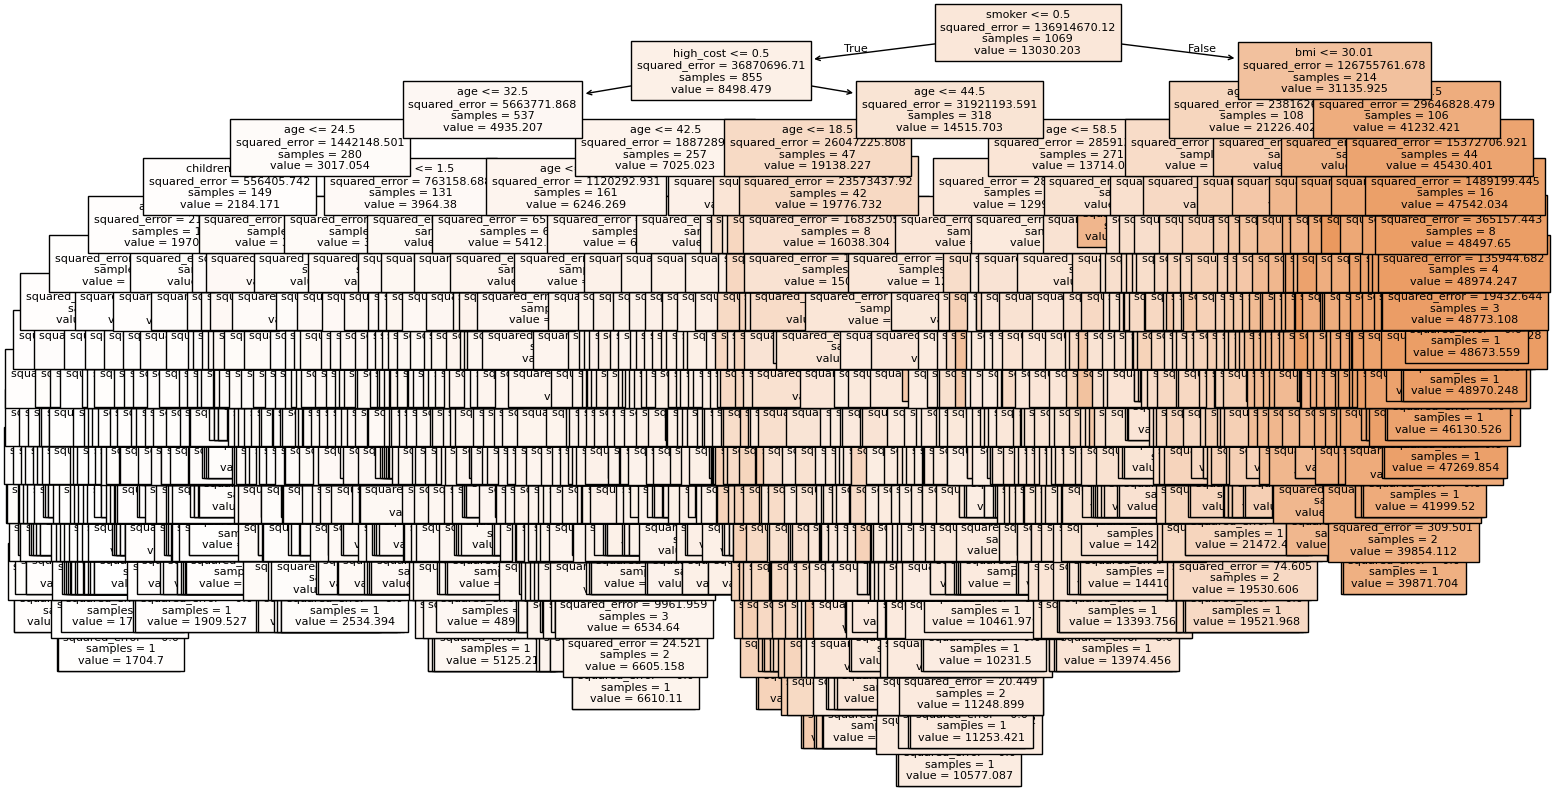

In [84]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18,10))
plot_tree(best_tree, feature_names=X.columns, filled=True, fontsize=8)
plt.show()



In [89]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

param_grid_reg = {
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

tree_reg = DecisionTreeRegressor(random_state=42)

grid_reg = GridSearchCV(
    estimator=tree_reg,
    param_grid=param_grid_reg,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_reg.fit(X_train, y_train)

print("Mejores parámetros (regresión):", grid_reg.best_params_)
best_reg_model = grid_reg.best_estimator_



Mejores parámetros (regresión): {'criterion': 'squared_error', 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}


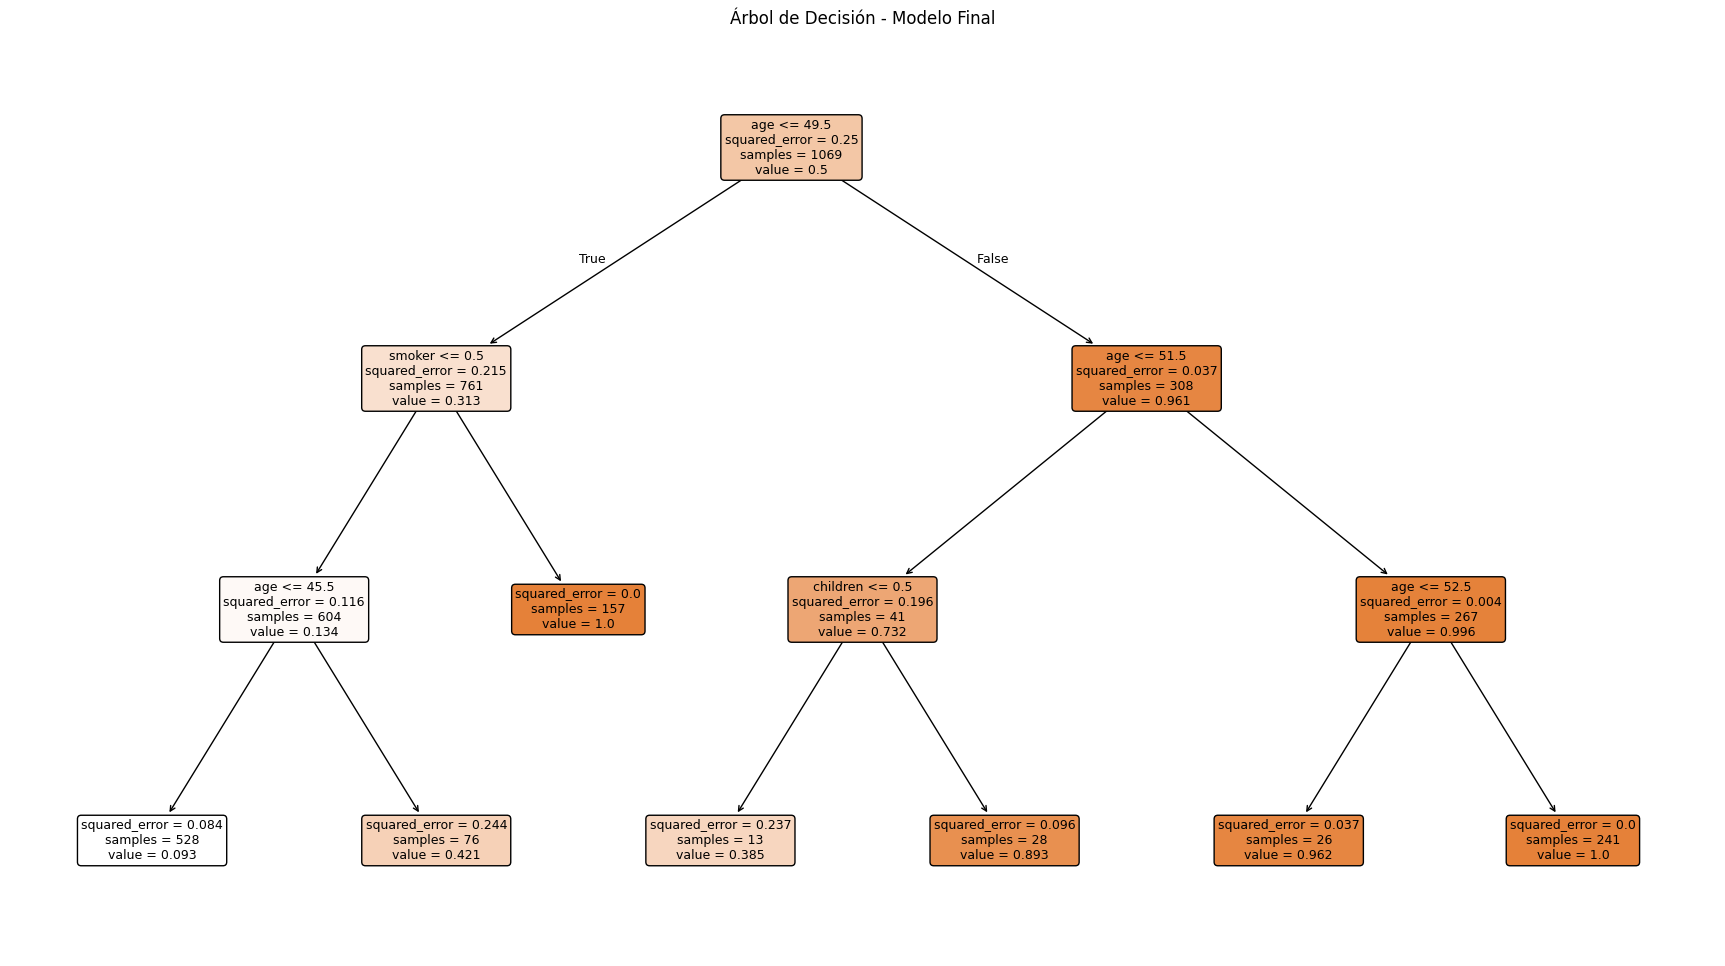

In [98]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(22, 12))
plot_tree(
    best_reg_model,               # o best_clf_model si quieres el de clasificación
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Árbol de Decisión - Modelo Final")
plt.show()

Clasificasión:

In [85]:
df_encoded['high_cost'] = (df_encoded['charges'] > df_encoded['charges'].median()).astype(int)

In [86]:
X = df_encoded.drop(['charges', 'high_cost'], axis=1)
y = df_encoded['high_cost']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [87]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

criterios = ['gini', 'entropy', 'log_loss']
resultados_clf = {}

for crit in criterios:
    clf = DecisionTreeClassifier(criterion=crit, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    resultados_clf[crit] = acc

    print(f"\n=== Criterio: {crit} ===")
    print("Accuracy:", acc)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))




=== Criterio: gini ===
Accuracy: 0.9104477611940298
[[122  12]
 [ 12 122]]
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       134
           1       0.91      0.91      0.91       134

    accuracy                           0.91       268
   macro avg       0.91      0.91      0.91       268
weighted avg       0.91      0.91      0.91       268


=== Criterio: entropy ===
Accuracy: 0.8917910447761194
[[119  15]
 [ 14 120]]
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       134
           1       0.89      0.90      0.89       134

    accuracy                           0.89       268
   macro avg       0.89      0.89      0.89       268
weighted avg       0.89      0.89      0.89       268


=== Criterio: log_loss ===
Accuracy: 0.8917910447761194
[[119  15]
 [ 14 120]]
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       134
  

In [88]:
best_clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
best_clf.fit(X_train, y_train)

importances_clf = pd.Series(best_clf.feature_importances_, index=X.columns)
importances_clf.sort_values(ascending=False)



age                 0.461064
smoker              0.306723
bmi                 0.110022
children            0.055151
sex                 0.020657
region_southwest    0.018849
region_northwest    0.014750
region_southeast    0.012785
dtype: float64

In [90]:
from sklearn.tree import DecisionTreeClassifier

param_grid_clf = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

tree_clf = DecisionTreeClassifier(random_state=42)

grid_clf = GridSearchCV(
    estimator=tree_clf,
    param_grid=param_grid_clf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_clf.fit(X_train, y_train)

print("Mejores parámetros (clasificación):", grid_clf.best_params_)
best_clf_model = grid_clf.best_estimator_



Mejores parámetros (clasificación): {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}


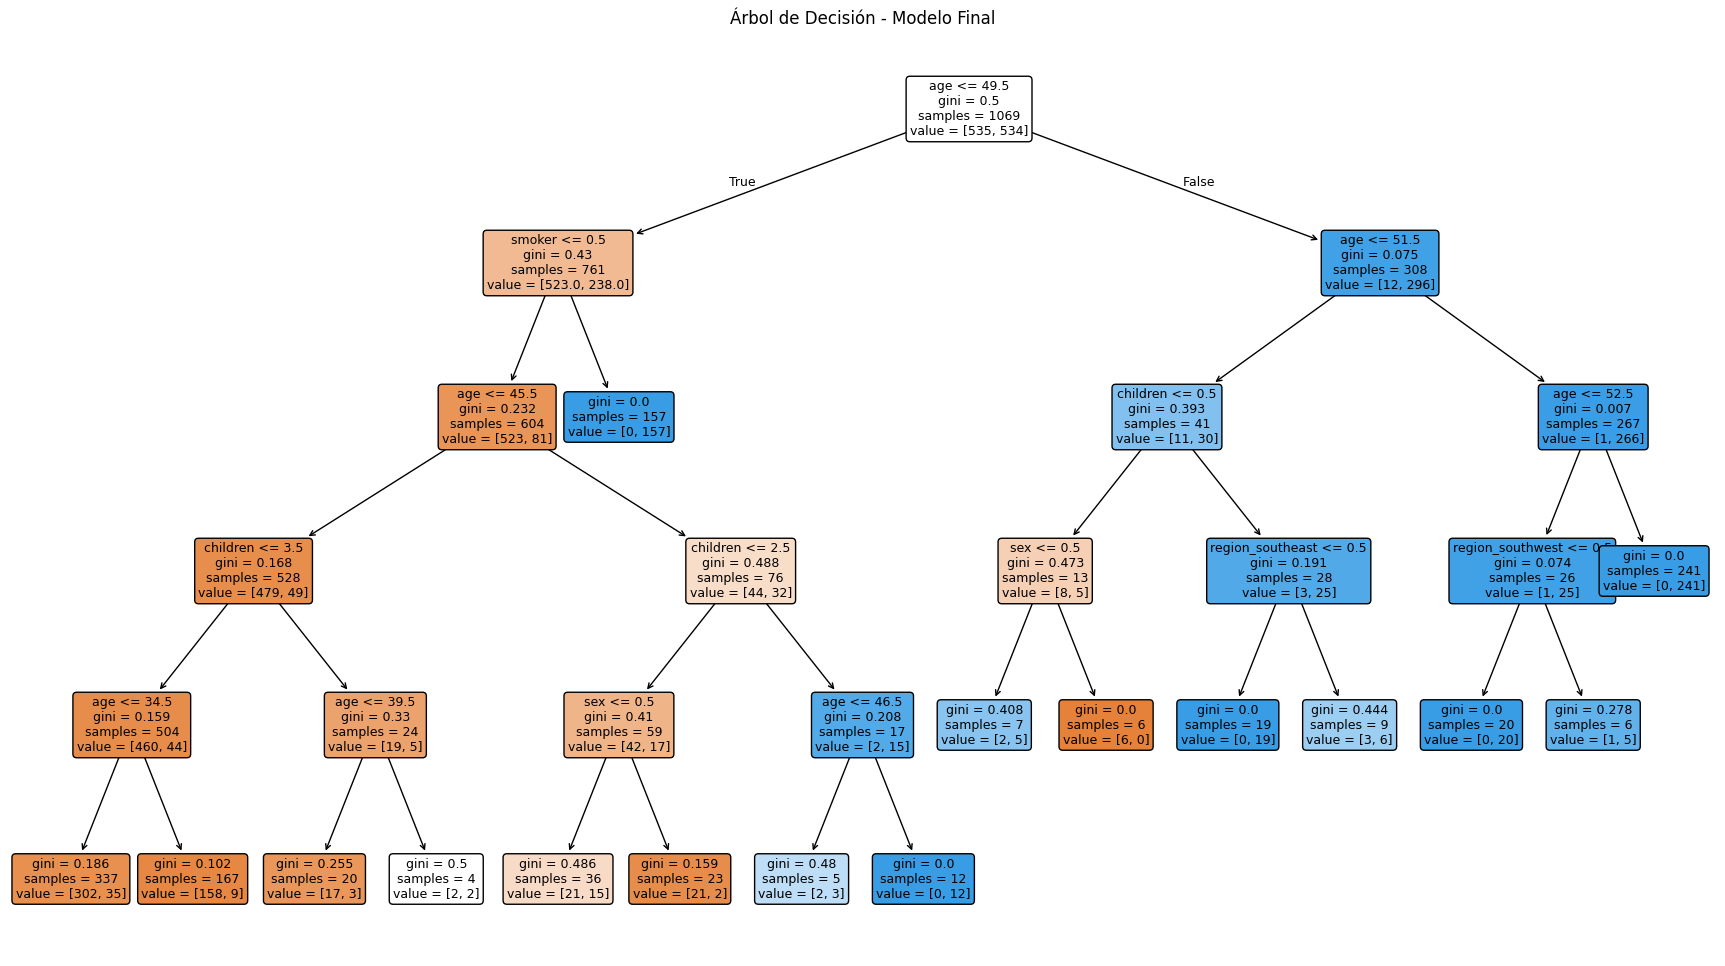

In [99]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(22, 12))
plot_tree(
    best_clf_model, 
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Árbol de Decisión - Modelo Final")
plt.show()



In [100]:
import joblib
import os
os.makedirs("models", exist_ok=True)

In [101]:
joblib.dump(best_reg_model, "models/tree_regression.pkl")
joblib.dump(best_clf_model, "models/tree_classification.pkl")



['models/tree_classification.pkl']